In [44]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, roc_auc_score, roc_curve
from sklearn.preprocessing import label_binarize
import os
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
import pandas as pd
import shap
import matplotlib.cm as cm
from tensorflow.keras.preprocessing import image

In [2]:
tf.random.set_seed(42)
np.random.seed(42)

In [3]:
IMG_SIZE = (128, 128)
BATCH_SIZE = 32
EPOCHS = 20

In [4]:
train_dir = 'Project3_Dataset/Train'
test_dir = 'Project3_Dataset/Test'

# phase 1

## train

In [5]:
print("Loading Training and Validation Data...")
train_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

Loading Training and Validation Data...
Found 40000 files belonging to 10 classes.
Using 32000 files for training.
Found 40000 files belonging to 10 classes.
Using 8000 files for validation.


## test

In [6]:
print("\nLoading Test Data...")
test_ds = tf.keras.utils.image_dataset_from_directory(
    test_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)


Loading Test Data...
Found 9000 files belonging to 10 classes.


In [7]:
class_names = train_ds.class_names
num_classes = len(class_names)
print(f"\nClasses: {class_names}")


Classes: ['Cheetah', 'Deer', 'Giraffe', 'Hyena', 'Jaguar', 'Leopard', 'Tapir Calf', 'Tiger', 'Whale Shark', 'Zebra']


# optimazation

In [8]:
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)
test_ds = test_ds.cache().prefetch(buffer_size=AUTOTUNE)

## model with overfitting

In [10]:
model = models.Sequential([
    layers.Rescaling(1./255, input_shape=(128, 128, 3)),
    
    layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2)),
    
    layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2)),
    
    layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2)),
    
    layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2)),
    
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(num_classes, activation='softmax')
])

In [11]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_1 (Rescaling)         │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 32, 32, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │       262,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 356,106 (1.36 MB)

 Trainable params: 356,106 (1.36 MB)

 Non-trainable params: 0 (0.00 B)

## compile the model

In [12]:
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

## train the model

In [13]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS
)

Epoch 1/20
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 86s 85ms/step - accuracy: 0.5125 - loss: 1.3004 - val_accuracy: 0.7303 - val_loss: 0.7472
Epoch 2/20
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 63s 63ms/step - accuracy: 0.7579 - loss: 0.6592 - val_accuracy: 0.7795 - val_loss: 0.6069
Epoch 3/20
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 62s 62ms/step - accuracy: 0.8077 - loss: 0.5323 - val_accuracy: 0.7747 - val_loss: 0.6174
Epoch 4/20
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 62s 62ms/step - accuracy: 0.8363 - loss: 0.4535 - val_accuracy: 0.7826 - val_loss: 0.6070
Epoch 5/20
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 62s 62ms/step - accuracy: 0.8614 - loss: 0.3832 - val_accuracy: 0.8019 - val_loss: 0.5940
Epoch 6/20
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 63s 63ms/step - accuracy: 0.8827 - loss: 0.3272 - val_accuracy: 0.7881 - val_loss: 0.6793
Epoch 7/20
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 64s 64ms/step - accuracy: 0.8946 - loss: 0.2886 - val_accuracy: 0.8085 - val_loss: 0.6704
Epoch 8/20
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 64s 64ms/step - accuracy: 0.9102 -

## learning curve

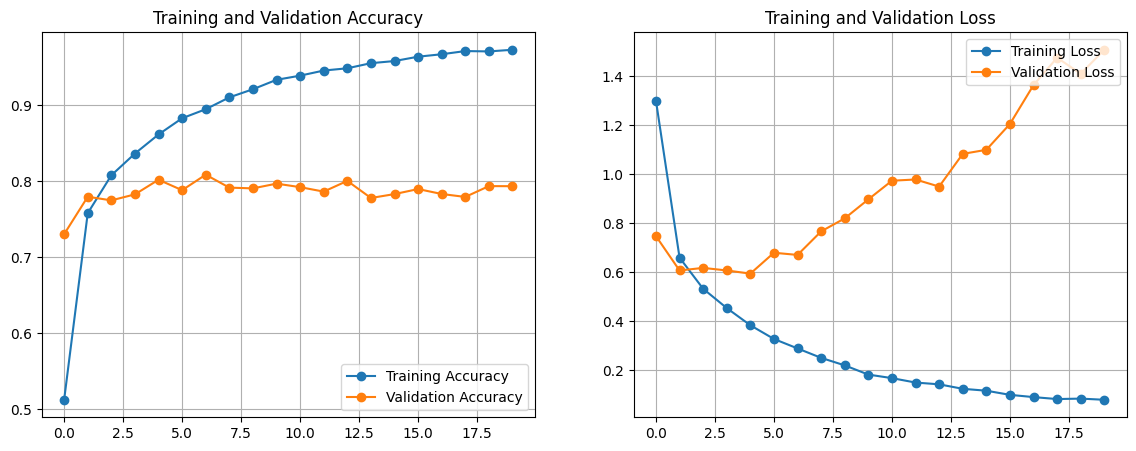

In [14]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(EPOCHS)

plt.figure(figsize=(14, 5))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy', marker='o')
plt.plot(epochs_range, val_acc, label='Validation Accuracy', marker='o')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss', marker='o')
plt.plot(epochs_range, val_loss, label='Validation Loss', marker='o')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.grid(True)

plt.show()

## test

In [15]:
y_true = np.concatenate([y for x, y in test_ds], axis=0)

# prediction
y_pred_prob = model.predict(test_ds)
y_pred = np.argmax(y_pred_prob, axis=1)

print("\n--- Classification Report ---")
print(classification_report(y_true, y_pred, target_names=class_names))

y_true_bin = label_binarize(y_true, classes=range(num_classes))
auc_score = roc_auc_score(y_true_bin, y_pred_prob, multi_class='ovr')
print(f"Overall ROC AUC Score: {auc_score:.4f}\n")

282/282 ━━━━━━━━━━━━━━━━━━━━ 6s 21ms/step

--- Classification Report ---
              precision    recall  f1-score   support

     Cheetah       0.64      0.76      0.69       900
        Deer       0.84      0.75      0.79       900
     Giraffe       0.93      0.78      0.85       900
       Hyena       0.73      0.78      0.75       900
      Jaguar       0.66      0.50      0.57       900
     Leopard       0.49      0.61      0.54       900
  Tapir Calf       0.84      0.88      0.86       900
       Tiger       0.92      0.84      0.88       900
 Whale Shark       0.90      0.92      0.91       900
       Zebra       0.92      0.94      0.93       900

    accuracy                           0.77      9000
   macro avg       0.79      0.77      0.78      9000
weighted avg       0.79      0.77      0.78      9000

Overall ROC AUC Score: 0.9704



## Confusion Matrix

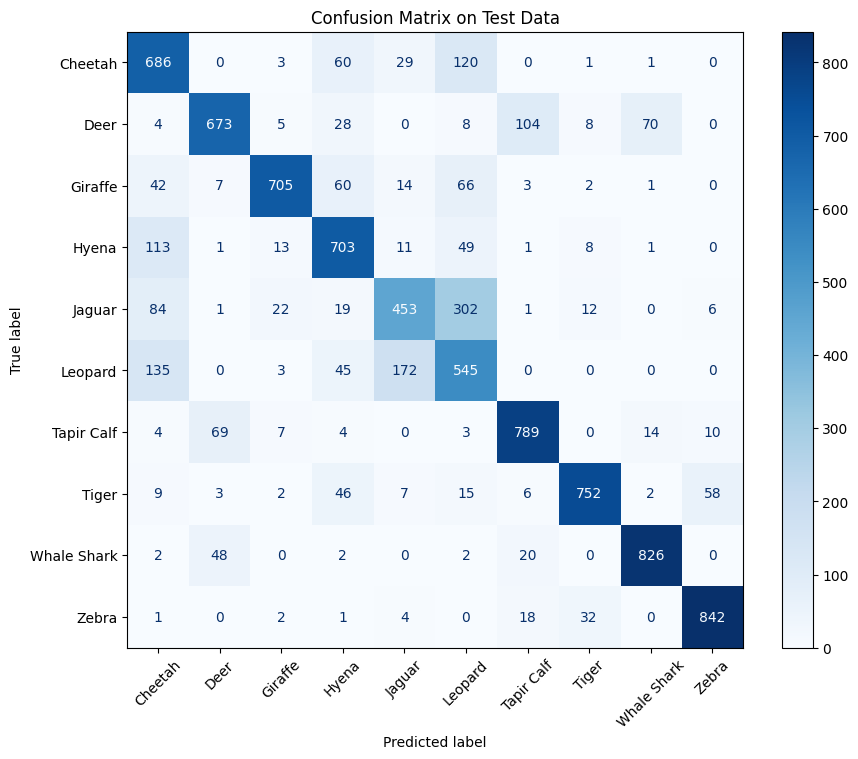

In [16]:
cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
fig, ax = plt.subplots(figsize=(10, 8))
disp.plot(cmap=plt.cm.Blues, ax=ax, xticks_rotation=45)
plt.title('Confusion Matrix on Test Data')
plt.show()

## ROC Curve

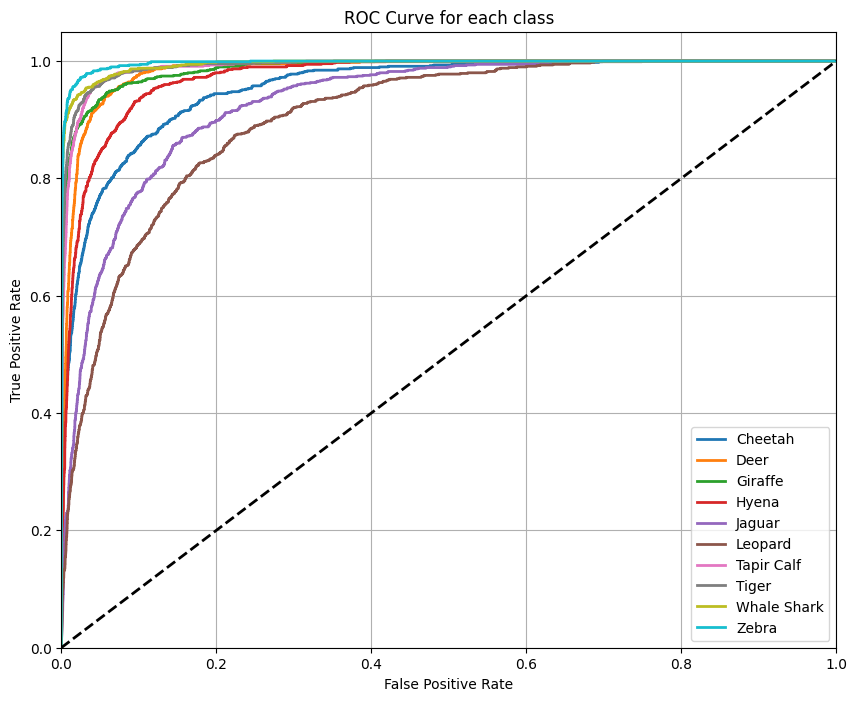

In [17]:
plt.figure(figsize=(10, 8))
for i in range(num_classes):
    fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_pred_prob[:, i])
    plt.plot(fpr, tpr, lw=2, label=f'{class_names[i]}')

plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for each class')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

Found 9000 files belonging to 10 classes.
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step


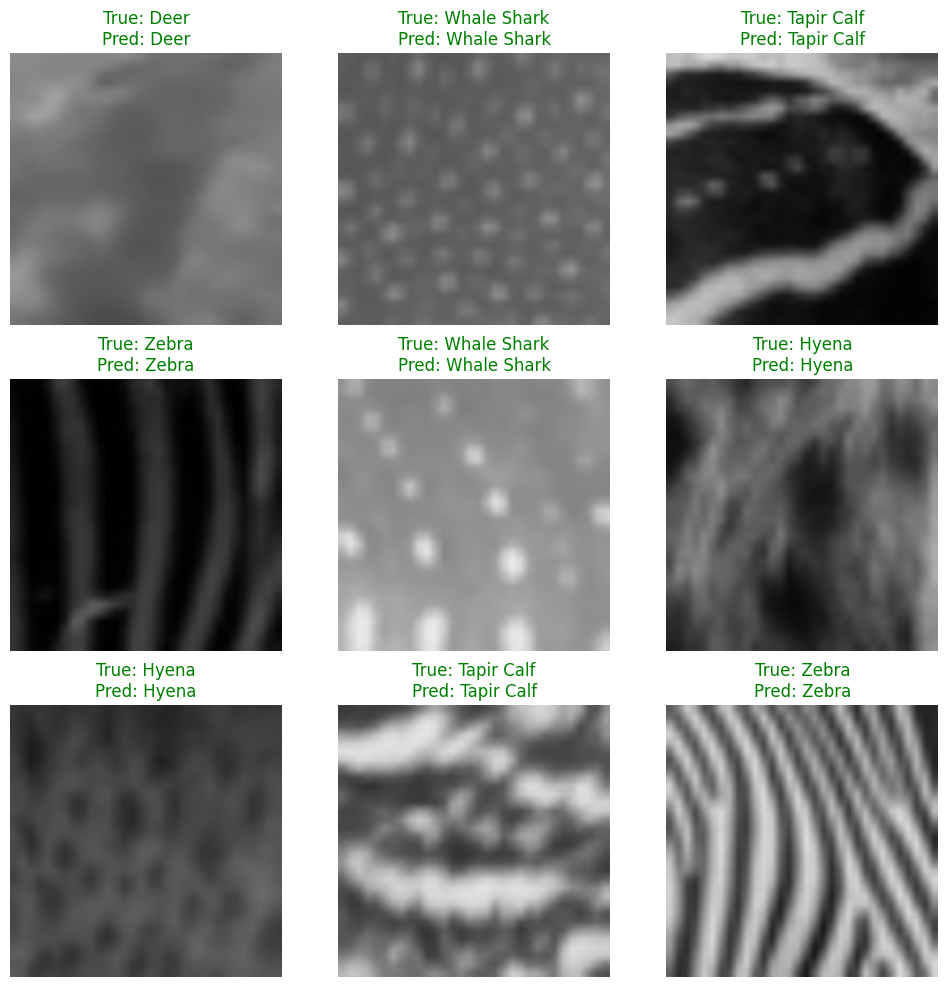

In [ ]:
test_batch_ds = tf.keras.utils.image_dataset_from_directory(
    test_dir, image_size=IMG_SIZE, batch_size=9, shuffle=True
)

for images, labels in test_batch_ds.take(1):
    preds_prob = model.predict(images)
    preds = np.argmax(preds_prob, axis=1)
    
    plt.figure(figsize=(12, 12))
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        
        true_label = class_names[labels[i]]
        pred_label = class_names[preds[i]]
        
        color = "green" if true_label == pred_label else "red"
        plt.title(f"True: {true_label}\nPred: {pred_label}", color=color)
        plt.axis("off")
        
plt.show()

---
# phase2

## Data Augmentation layers

In [19]:
data_augmentation = tf.keras.Sequential([
  layers.RandomFlip("horizontal", input_shape=(128, 128, 3)),
  layers.RandomRotation(0.15),
  layers.RandomZoom(0.2),
  layers.RandomTranslation(height_factor=0.1, width_factor=0.1),
], name="data_augmentation")

print("Data Augmentation Pipeline Created.")

Data Augmentation Pipeline Created.


C:\Users\sasan_wmsfg3b\AppData\Roaming\Python\Python313\site-packages\keras\src\layers\preprocessing\data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


## Hyperparameter Tuning

In [20]:
model_A = models.Sequential([
    data_augmentation,
    layers.Rescaling(1./255),
    
    layers.Conv2D(32, (3, 3), padding='same'),
    layers.BatchNormalization(),
    layers.LeakyReLU(alpha=0.1),
    layers.MaxPooling2D((2, 2)),
    
    layers.Conv2D(64, (3, 3), padding='same'),
    layers.BatchNormalization(),
    layers.LeakyReLU(alpha=0.1),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.2), 
    
    layers.Conv2D(64, (3, 3), padding='same'),
    layers.BatchNormalization(),
    layers.LeakyReLU(alpha=0.1),
    layers.MaxPooling2D((2, 2)),
    
    layers.Flatten(),
    layers.Dense(64),
    layers.BatchNormalization(),
    layers.LeakyReLU(alpha=0.1),
    layers.Dropout(0.4), 
    layers.Dense(num_classes, activation='softmax')
])

C:\Users\sasan_wmsfg3b\AppData\Roaming\Python\Python313\site-packages\keras\src\layers\activations\leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


In [ ]:
model_A.compile(optimizer=tf.keras.optimizers.RMSprop(learning_rate=0.001),
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

print("Training Model A (LeakyReLU + RMSprop)...")
history_A = model_A.fit(train_ds, validation_data=val_ds, epochs=10) # only for test

Training Model A (LeakyReLU + RMSprop)...
Epoch 1/10
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 175s 173ms/step - accuracy: 0.4355 - loss: 1.5328 - val_accuracy: 0.5756 - val_loss: 1.1255
Epoch 2/10
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 171s 171ms/step - accuracy: 0.5988 - loss: 1.0578 - val_accuracy: 0.6917 - val_loss: 0.8336
Epoch 3/10
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 170s 170ms/step - accuracy: 0.6419 - loss: 0.9483 - val_accuracy: 0.7262 - val_loss: 0.7330
Epoch 4/10
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 169s 169ms/step - accuracy: 0.6718 - loss: 0.8763 - val_accuracy: 0.7345 - val_loss: 0.7160
Epoch 5/10
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 169s 169ms/step - accuracy: 0.6895 - loss: 0.8334 - val_accuracy: 0.7585 - val_loss: 0.6308
Epoch 6/10
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 170s 170ms/step - accuracy: 0.6993 - loss: 0.8016 - val_accuracy: 0.7120 - val_loss: 0.7692
Epoch 7/10
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 171s 171ms/step - accuracy: 0.7101 - loss: 0.7790 - val_accuracy: 0.7067 - val_loss: 0.7741
Epoch 8/10
1000/1000

# second model

In [23]:
final_model = models.Sequential([
    data_augmentation,
    layers.Rescaling(1./255),
    
    layers.Conv2D(32, (3, 3), padding='same', activation='elu', kernel_regularizer=l2(0.001)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    
    layers.Conv2D(64, (3, 3), padding='same', activation='elu', kernel_regularizer=l2(0.001)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25),
    
    layers.Conv2D(128, (3, 3), padding='same', activation='elu', kernel_regularizer=l2(0.001)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.3),
    
    layers.Flatten(),
    layers.Dense(128, activation='elu', kernel_regularizer=l2(0.001)),
    layers.BatchNormalization(),
    layers.Dropout(0.5),
    layers.Dense(num_classes, activation='softmax')
])

In [24]:
final_model.compile(optimizer=tf.keras.optimizers.Nadam(learning_rate=0.001),
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

## callbacks to stop over fitting

In [25]:
early_stop = EarlyStopping(monitor='val_loss', patience=7, restore_best_weights=True, verbose=1)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6, verbose=1)

In [27]:
print("Training Final Model with Callbacks...")
EPOCHS_PHASE2 = 15

history_final = final_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS_PHASE2,
    callbacks=[early_stop, reduce_lr]
)

Training Final Model with Callbacks...
Epoch 1/15
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 214s 214ms/step - accuracy: 0.7312 - loss: 1.1336 - val_accuracy: 0.7849 - val_loss: 0.9786 - learning_rate: 5.0000e-04
Epoch 2/15
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 212s 212ms/step - accuracy: 0.7269 - loss: 1.1344 - val_accuracy: 0.7875 - val_loss: 0.9890 - learning_rate: 5.0000e-04
Epoch 3/15
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 207s 207ms/step - accuracy: 0.7339 - loss: 1.1234 - val_accuracy: 0.7726 - val_loss: 1.0069 - learning_rate: 5.0000e-04
Epoch 4/15
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 0s 199ms/step - accuracy: 0.7298 - loss: 1.1245
Epoch 4: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 207s 207ms/step - accuracy: 0.7302 - loss: 1.1233 - val_accuracy: 0.7801 - val_loss: 0.9988 - learning_rate: 5.0000e-04
Epoch 5/15
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 207s 207ms/step - accuracy: 0.7466 - loss: 1.0433 - val_accuracy: 0.7811 - val_loss: 0.9209 - learning_rate: 2.5000e

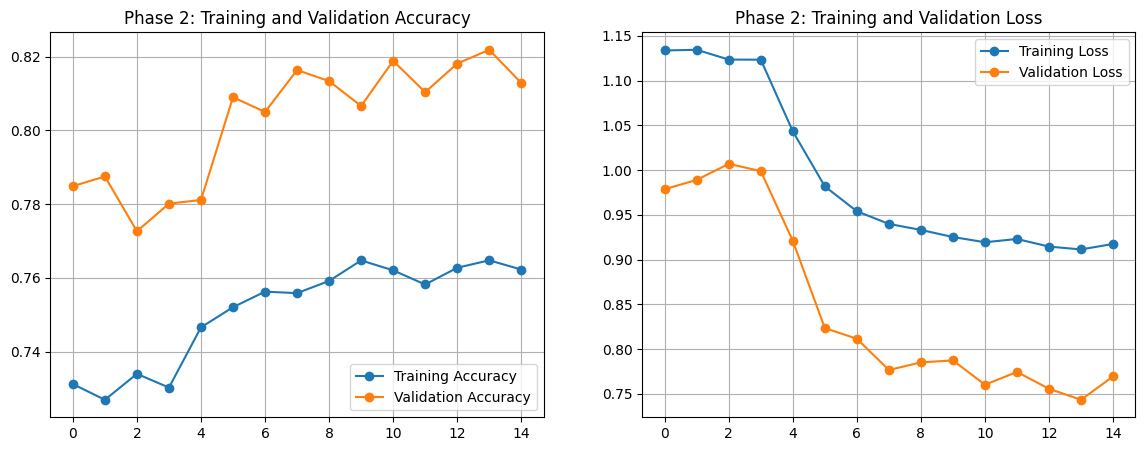


Model saved successfully as 'phase2_best_model.h5'


In [ ]:
acc = history_final.history['accuracy']
val_acc = history_final.history['val_accuracy']
loss = history_final.history['loss']
val_loss = history_final.history['val_loss']

epochs_range = range(len(acc))

plt.figure(figsize=(14, 5))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy', marker='o')
plt.plot(epochs_range, val_acc, label='Validation Accuracy', marker='o')
plt.legend(loc='lower right')
plt.title('Phase 2: Training and Validation Accuracy')
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss', marker='o')
plt.plot(epochs_range, val_loss, label='Validation Loss', marker='o')
plt.legend(loc='upper right')
plt.title('Phase 2: Training and Validation Loss')
plt.grid(True)
plt.show()

final_model.save('phase2_best_model.h5')
print("\nModel saved successfully as 'phase2_best_model.h5'")

In [30]:
unseen_dir = 'Project3_Dataset/Unseen'
student_id = '4012262061-4012262050'

In [32]:
results = []

for img_name in os.listdir(unseen_dir):
    img_path = os.path.join(unseen_dir, img_name)
    
    if os.path.isfile(img_path) and img_name.lower().endswith(('.png', '.jpg', '.jpeg')):
        img = image.load_img(img_path, target_size=IMG_SIZE)
        img_array = image.img_to_array(img)
        img_array = tf.expand_dims(img_array, 0) 
        
        predictions = final_model.predict(img_array, verbose=0)
        predicted_class_idx = np.argmax(predictions[0])
        predicted_class_name = class_names[predicted_class_idx]
        
        results.append({
            'Image_Name': img_name,
            'Predicted_Category': predicted_class_name
        })

df = pd.DataFrame(results)
csv_filename = f"{student_id}.csv"
df.to_csv(csv_filename, index=False)

print(f"\nPredictions complete! Saved to {csv_filename}")
df.head() 


Predictions complete! Saved to 4012262061-4012262050.csv


,Image_Name,Predicted_Category
0,1.png,Hyena
1,10.png,Zebra
2,100.png,Hyena
3,1000.png,Hyena
4,101.png,Zebra


---
# phase3

In [46]:
model = tf.keras.models.load_model('phase2_best_model.h5')

In [48]:
conv_layers = []
for layer in model.layers:
    if 'conv2d' in layer.name:
        conv_layers.append(layer)

print(f"Found {len(conv_layers)} Convolutional layers.")

Found 3 Convolutional layers.


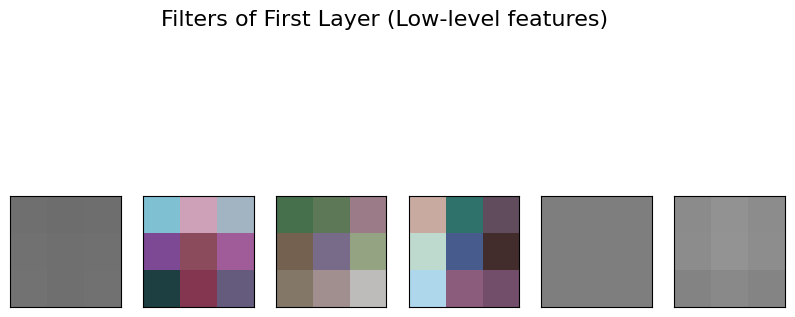

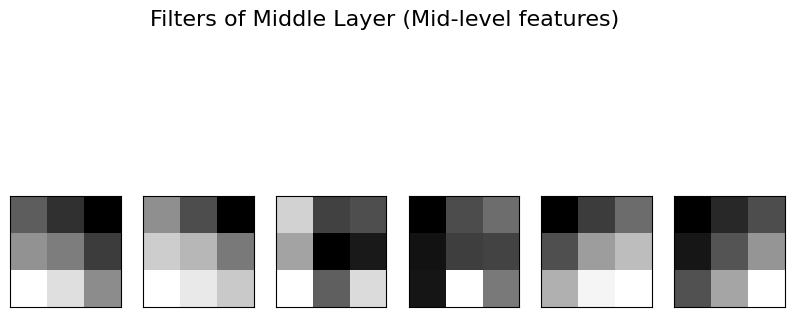

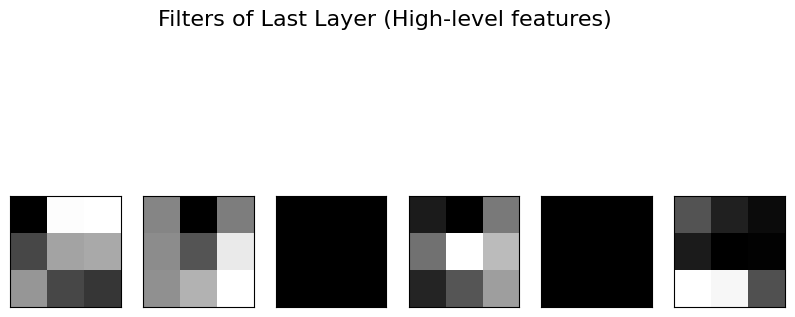

In [35]:
def plot_filters(layer, layer_name, num_filters=6):
    weights, biases = layer.get_weights()
    f_min, f_max = weights.min(), weights.max()
    weights = (weights - f_min) / (f_max - f_min)
    
    plt.figure(figsize=(10, 5))
    plt.suptitle(f'Filters of {layer_name}', fontsize=16)
    
    for i in range(num_filters):
        f = weights[:, :, :, i]
        
        if f.shape[2] == 3:
            ax = plt.subplot(1, num_filters, i+1)
            ax.set_xticks([])
            ax.set_yticks([])
            plt.imshow(f)
        else:
            ax = plt.subplot(1, num_filters, i+1)
            ax.set_xticks([])
            ax.set_yticks([])
            plt.imshow(f[:, :, 0], cmap='gray')
            
    plt.show()

plot_filters(conv_layers[0], "First Layer (Low-level features)")
plot_filters(conv_layers[1], "Middle Layer (Mid-level features)")
plot_filters(conv_layers[-1], "Last Layer (High-level features)")

در هر لایه چه الگوهایی دیده می‌شود و شبکه چه نوع ویژگی‌هایی را استخراج کرده است؟

لایه اول : در فیلترهای این لایه الگوهای بسیار ساده و پایه‌ای دیده می‌شود. شبکه در این لایه سعی می‌کند لبه‌ها، خطوط صاف، گوشه‌ها و کنتراست رنگ‌های پایه را استخراج کند. مثلاً تفاوت رنگ پس‌زمینه با رنگ بدن حیوان

لایه‌های میانی : در این لایه‌ها، شبکه الگوهای پیچیده‌تری را از ترکیب خطوط لایه قبل می‌سازد. در این پروژه که مربوط به پوست حیوانات است، این لایه سعی در یادگیری بافت‌ها مانند خال‌های پلنگ  یا خطوط گورخر  دارد

لایه آخر : الگوهای این لایه برای چشم انسان کمتر قابل تشخیص است، اما برای شبکه معنای عمیقی دارد. شبکه در این لایه ویژگی‌های سطح بالا را استخراج می‌کند که مستقیماً به کلاس حیوان اشاره دارد؛ مانند شکل کلی گوش‌ها، پوزه یا قالب کلی بدن حیوان

## describe with SHAP

In [51]:
background_images = []
for images, labels in train_ds.unbatch().take(50):
    background_images.append(images.numpy())
background_images = np.array(background_images)

In [52]:
test_images = []
test_labels_list = []
for images, labels in test_ds.unbatch().take(3): 
    test_images.append(images.numpy())
    test_labels_list.append(labels.numpy())
test_images = np.array(test_images)

print("Preparing SHAP GradientExplainer")

Preparing SHAP GradientExplainer


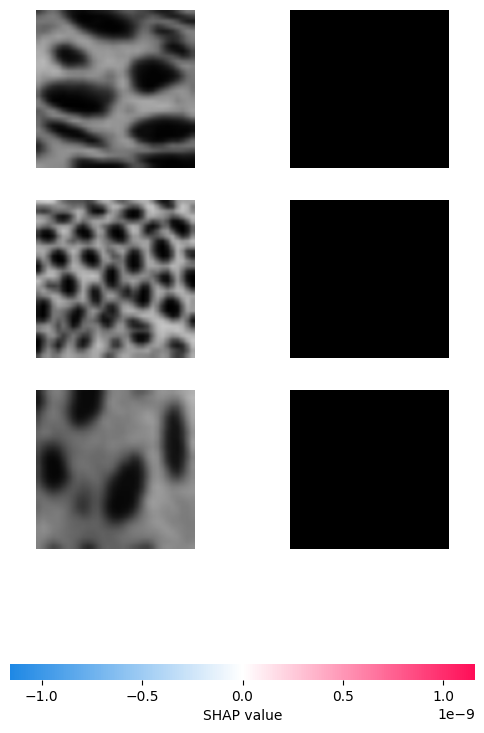

Image 1 True Class: Cheetah
Image 2 True Class: Cheetah
Image 3 True Class: Cheetah


In [53]:
explainer = shap.GradientExplainer(model, background_images)
shap_values = explainer.shap_values(test_images)
shap.image_plot(shap_values, test_images.astype(np.int32))
for i, lbl in enumerate(test_labels_list):
    print(f"Image {i+1} True Class: {class_names[lbl]}")

تحلیل خروجی GradientExplainer در SHAP:

در نمودارهای تولید شده توسط SHAP، ما تاثیر هر پیکسل از تصویر را بر روی خروجی نهایی شبکه‌ی عصبی مشاهده می‌کنیم.

پیکسل‌های قرمز (Red Pixels): نشان‌دهنده ویژگی‌ها یا قسمت‌هایی از تصویر هستند که تاثیر مثبت در پیش‌بینی آن کلاس خاص داشته‌اند (احتمال تعلق تصویر به آن حیوان را بالا برده‌اند). برای مثال، اگر تصویر یک گورخر باشد، پیکسل‌های قرمز دقیقاً روی خطوط سیاه و سفید بدن او قرار می‌گیرند.

پیکسل‌های آبی (Blue Pixels): نشان‌دهنده قسمت‌هایی هستند که تاثیر منفی داشته‌اند (احتمال تعلق تصویر به آن کلاس را کاهش داده‌اند).

نتیجه‌گیری: این خروجی‌ها اثبات می‌کنند که مدل ما (Black box) تصمیمات خود را بر اساس ویژگی‌های منطقی و صحیح تصویر (مثل پترن پوست حیوانات) می‌گیرد و نه بر اساس نویزهای پس‌زمینه (مثل درخت یا چمن پشت حیوان).